<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Random Forest**

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/movies_metadata.csv', sep=',',
    engine='python',
    quoting=3,
    on_bad_lines='skip'
    )

df.head()

"adult  \
"False ""{'id': 10194   'name': 'Toy Story Collection'            'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000   ""[{'id': 16      'name': 'Animation'}  {'id': 35              'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862                                                                                         tt0114709   
       ""{'id': 119050  'name': 'Grumpy Old Men Collection'       'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0          ""[{'id': 10749   'name': 'Romance'}    {'id': 35              'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en                                                                                   Grumpier Old Men   
       NaN             16000000                                  ""[{'id': 35                                       'name': 'Comedy'}                                   {'id': 18  'name': 'Drama'} {'id': 10749          'name': 'Romance'}]"" NaN                   31357         tt0114885             en                                   Waiting to Exhale                                                                        ""Cheated on   
       ""{'id': 96871   'name': 'Father of the Bride Collection'  'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg' 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.... 0          ""[{'id': 35      'name': 'Comedy'}]"" NaN                    11862                 tt0113041     en                    Father of the Bride Part II          ""Just when George Banks has recovered from his...   he receives the news that she's pregnant ... ...   
       NaN             62000000                                  ""[{'id': 35                                       'name': 'Comedy'}                                   {'id': 18  'name': 'Drama'} {'id': 10749          'name': 'Romance'}]"" NaN                   9087          tt0112346             en                                   The American President                                       ""Widowed U.S. president Andrew Shepherd   

                                                                                                                                                                                                                                                                                                                                                                                                                               belongs_to_collection  \
"False ""{'id': 10194   'name': 'Toy Story Collection'            'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000   ""[{'id': 16      'name': 'Animation'}  {'id': 35              'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862                                                                                                en   
       ""{'id': 119050  'name': 'Grumpy Old Men Collection'       'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0          ""[{'id': 10749   'name': 'Romance'}    {'id': 35              'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en                                                  ""A family wedding reignites the ancient feud ...   
       NaN             16000000                                  ""[{'id': 35                                       'name': 'Comedy'}                                   {'id': 18  'name': 'Drama'} {'id': 10749          'name': 'Romance'}]"" NaN                   31357         tt0114885             en                                   Waiting to Exhale                                                           mistreated and stepped on   
       ""{'id': 96871   'name

In [25]:
print(df.shape)
print(df.columns)
df.head(2)

(33390, 24)
Index(['"adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count"'],
      dtype='object')


"adult  \
"False ""{'id': 10194  'name': 'Toy Story Collection'      'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000 ""[{'id': 16    'name': 'Animation'} {'id': 35 'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862         tt0114709   
       ""{'id': 119050 'name': 'Grumpy Old Men Collection' 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0        ""[{'id': 10749 'name': 'Romance'}   {'id': 35 'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en   Grumpier Old Men   

                                                                                                                                                                                                                                                                                                                                                       belongs_to_collection  \
"False ""{'id': 10194  'name': 'Toy Story Collection'      'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000 ""[{'id': 16    'name': 'Animation'} {'id': 35 'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862                                                 en   
       ""{'id': 119050 'name': 'Grumpy Old Men Collection' 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0        ""[{'id': 10749 'name': 'Romance'}   {'id': 35 'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en   ""A family wedding reignites the ancient feud ...   

                                                                                                                                                                                                                                                                                                                                                                      budget  \
"False ""{'id': 10194  'name': 'Toy Story Collection'      'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000 ""[{'id': 16    'name': 'Animation'} {'id': 35 'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862                                          Toy Story   
       ""{'id': 119050 'name': 'Grumpy Old Men Collection' 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0        ""[{'id': 10749 'name': 'Romance'}   {'id': 35 'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en    a sultry Italian divorcée opens a restaurant ...   

                                                                                                                                                                                                                                                                                                                                                                      genres  \
"False ""{'id': 10194  'name': 'Toy Story Collection'      'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000 ""[{'id': 16    'name': 'Animation'} {'id': 35 'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862                                     ""Led by Woody   
       ""{'id': 119050 'name': 'Grumpy Old Men Collection' 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0        ""[{'id': 10749 'name': 'Romance'}   {'id': 35 'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en    alarming the locals who worry she'll scare th...   

    

In [26]:
df = df.drop_duplicates().reset_index(drop=True)

df = df[['title', 'overview', 'genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [27]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

In [28]:
df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [29]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['tags'])

# Convert numeric
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce').fillna(0)
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce').fillna(0)

X_num = df[['popularity']].values

# Combine
X = hstack((tfidf_matrix, X_num)).tocsr()

In [31]:
df['target'] = df['vote_average'].apply(lambda x: 1 if x >= 6 else 0)

y = df['target']

In [32]:
from sklearn.model_selection import train_test_split

X_dense = X.toarray()

X_train, X_test, y_train, y_test = train_test_split(
    X_dense, y, test_size=0.2, random_state=42
)

RANDOM FOREST MODEL

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [34]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== RANDOM FOREST ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

=== RANDOM FOREST ===
Accuracy : 0.8850574712643678
Precision: 0.56
Recall   : 0.2641509433962264
F1 Score : 0.358974358974359


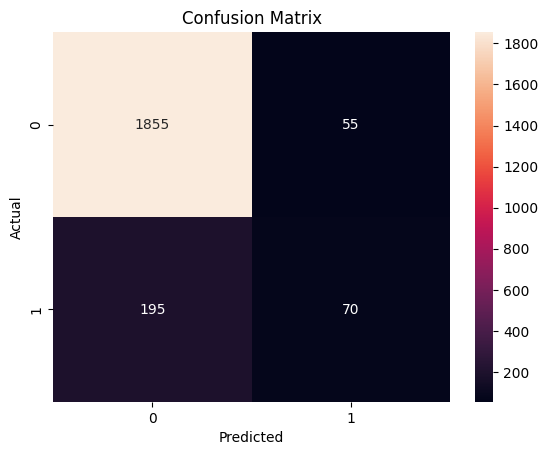

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

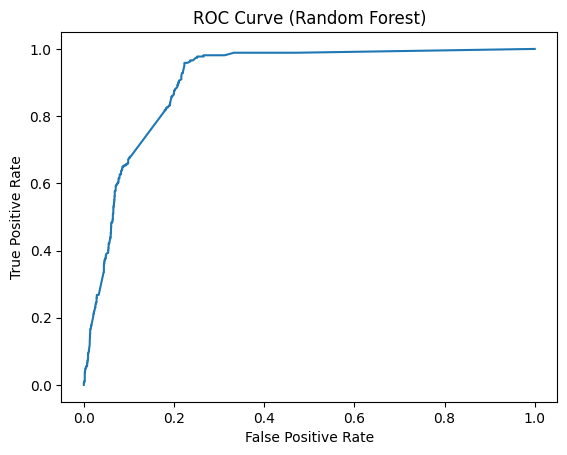

ROC-AUC Score: 0.9061167638051961


In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.show()

print("ROC-AUC Score:", auc)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.97      0.94      1910
           1       0.56      0.26      0.36       265

    accuracy                           0.89      2175
   macro avg       0.73      0.62      0.65      2175
weighted avg       0.86      0.89      0.87      2175



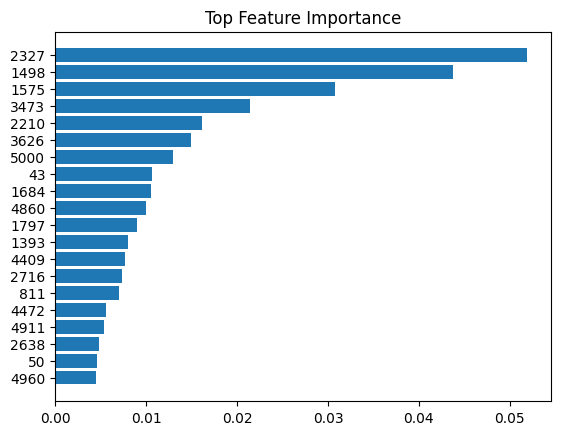

In [39]:
import numpy as np

importances = rf.feature_importances_

indices_imp = np.argsort(importances)[-20:]

plt.figure()
plt.barh(range(len(indices_imp)), importances[indices_imp])
plt.yticks(range(len(indices_imp)), indices_imp)
plt.title("Top Feature Importance")
plt.show()

In [40]:
df['title'] = df['title'].str.lower()
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def recommend_rf(movie_name, top_n=10):
    movie_name = movie_name.lower()

    if movie_name not in indices:
        return "Movie not found"

    # Predict probability for all movies
    probs = rf.predict_proba(X_dense)[:,1]

    df['score'] = probs

    recs = df[df['title'] != movie_name]

    recs = recs.sort_values(by=['score','popularity'], ascending=False)

    recommendations = recs['title'].head(top_n).values

    print(f"\nInput Movie: {movie_name}")
    print("\nRecommended Movies:\n")

    for i, movie in enumerate(recommendations, 1):
        print(f"{i}. {movie}")

In [41]:
movie = input("Enter movie name: ").lower()
recommend_rf(movie)

Enter movie name: toy story

Input Movie: toy story

Recommended Movies:

1. thunder rock
2. the woman next door
3. mother
4. the beautiful story
5. the charge of the light brigade
6. no way out
7. attila marcel
8. love
9. santa claus and the magic drum
10. adventures of zatôichi
